In [4]:
from dotenv import load_dotenv
load_dotenv()

import os

import numpy as np
from pixell import enmap, enplot, reproject
import glob
import matplotlib.pyplot as plt
import emcee, corner
from astropy.io import fits
import sys
from astropy import units as u, constants as const
sys.path.insert(0, '../src')
#sys.path.insert(0, "/home/gill/apps/szpack/python")
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
import yaml
import itertools
from pixell import enmap

import bandpass as bp
import covariance as cov
import model
import utils as ut

import SZpack as SZ

from astropy.coordinates import SkyCoord
import astropy.units as u

In [ ]:
cf = ut.get_config_file("../configs/case15_ajay.yaml")

dire_data = "/home/gill/research/ACT/bridge/data_paper/data/data/new_20210728/20210728"
data_ref = ut.imap_dim_check(enmap.read_map(f"{dire_data}/act_cut_dr6v2_pa6_f090_4way_coadd_map_srcfree.fits"))
data_wcs = data_ref.wcs
data_shape = data_ref.shape

freq = "98"
array = "pa6"
inst = "act"
scan = "dr6v2"

ra_pix = data_wcs.celestial.wcs_world2pix(cf['ps1_ra'], cf['ps1_dec'], 0)[0]
dec_pix = data_wcs.celestial.wcs_world2pix(cf['ps1_ra'], cf['ps1_dec'], 0)[1]

ps = model.PointSource(amplitude=1000, ra_pix=ra_pix, dec_pix=dec_pix)

xgrid, ygrid = np.meshgrid(np.arange(0, data_shape[1], 1), np.arange(0, data_shape[0], 1))

ps_map = ps.model(frequency="98", array="pa6", data_shape=data_shape)

print(f"ps_map shape: {ps_map.shape}")

ut.plot_image(data_ref, title="Reference map", cmap="viridis", interval_type="zscale")
ut.plot_image(ps_map, title="Point source map", cmap="viridis", interval_type="simple_norm")

beam_tmp = ut.get_2d_beam(freq=freq, 
                        array=array, 
                        inst=inst, 
                        data_shape=data_shape, 
                        version=str(scan),
                        data_wcs=data_wcs)

ps_map = np.fft.ifft2( np.fft.fft2(ps_map) * beam_tmp ).real

ut.plot_image(ps_map, title="Point source map convolved with beam", cmap="viridis", interval_type="simple_norm")

In [ ]:
def map_maker(mcmc_fname, cf_name, labels, burnin=1, thin=1):
    
    sampler = emcee.backends.HDFBackend(mcmc_fname)
    samples = sampler.get_chain(discard=burnin, flat=True, thin=thin)  
    samples_unflat = sampler.get_chain(discard=burnin)
    cf = ut.get_config_file(cf_name)

    ndim = len(labels)

    acc_frac = sampler.accepted / sampler.iteration

    print("*Average acceptance fraction is: {:.2f}%".format(np.mean(acc_frac)*100))
    
    dire_data = "/home/gill/research/ACT/bridge/data_paper/data/data/new_20210728/20210728"
    dire_data_planck = "/home/gill/research/ACT/bridge/data_paper/data/data/planck_no_reproj"

    region = ut.get_region(cf['region_center_ra'], 
                            cf['region_center_dec'], 
                            cf['region_width'])

    data_ref = ut.imap_dim_check(enmap.read_map(f"{dire_data}/act_cut_dr6v2_pa5_f098_4way_coadd_map_srcfree.fits", 
                                 box=region))
    
    data_wcs = data_ref.wcs
    data_shape = data_ref.shape
    theta = []
    pad = 0.17

    for idx, label in enumerate(labels):
        mcmc_run = np.percentile(samples[:, idx], [16, 50, 84])
        err = .5 * (mcmc_run[2] - mcmc_run[0])
                
        data = samples[:, idx]

        n = len(data)
        iqr = np.percentile(data, 75) - np.percentile(data, 25)
        bin_width = 2 * iqr * n**(-1/3)

        num_bins = int((np.max(data) - np.min(data)) / bin_width)

        hist, bin_edges = np.histogram(data, bins=num_bins, density=True)

        mode_bin = np.argmax(hist)
        mode_value = 0.5 * (bin_edges[mode_bin] + bin_edges[mode_bin + 1])

        mean = mode_value
        
        theta.append(mean)

        print("{}: {:.6f}, +/- {:.6f}".format(label, mean, err))

    ps1_ra_pix = data_wcs.celestial.wcs_world2pix(cf['ps1_ra'], cf['ps1_dec'], 0)[0]
    ps1_dec_pix = data_wcs.celestial.wcs_world2pix(cf['ps1_ra'], cf['ps1_dec'], 0)[1]

    c1 = model.Cluster(theta=theta, name="abell401", model_choice=cf["model_choice"])
    c2 = model.Cluster(theta=theta, name="abell399", model_choice=cf["model_choice"])
    fil = model.Filament(theta=theta, model_choice=cf["model_choice"])
    ps1 = model.PointSource(theta=theta,ra_pix=ps1_ra_pix, dec_pix=ps1_dec_pix)

    # 98 ACT
    freq = 98
    array = "pa5"

    ref_data_98 = ut.imap_dim_check(enmap.read_map(f"{dire_data}/act_cut_dr6v2_pa5_f098_4way_coadd_map_srcfree.fits", 
                                                   box=region))

    xgrid, ygrid = np.meshgrid(np.arange(0, data_shape[1], 1), np.arange(0, data_shape[0], 1))
    flux_factor_98 = ut.flux_factor(array, freq)
    ref_data_98 *= flux_factor_98

    c1_model = c1.szmodel(frequency=freq, 
                            array=array, 
                            z=cf['c1_z'],
                            muo=cf['c1_muo'],
                            xgrid=xgrid, 
                            ygrid=ygrid,
                            ellipticity_type="numerator")
    
    c2_model = c2.szmodel(frequency=freq,
                            array=array,
                            z=cf['c2_z'],
                            muo=cf['c2_muo'],
                            xgrid=xgrid,
                            ygrid=ygrid, 
                            ellipticity_type="numerator")
    
    fil_model = fil.szmodel(frequency=freq,
                            array=array,
                            xgrid=xgrid,
                            ygrid=ygrid, 
                            z=cf['fil_z'],
                            muo=cf['fil_muo'])
    
    ps1_model = ps1.model(frequency=freq,
                              array=array, 
                              data_shape=xgrid.shape)
    
    total_model = c1_model + c2_model + fil_model + ps1_model

    beam_98 = ut.get_2d_beam(data_shape=ref_data_98.shape, 
                             freq=freq, 
                             array=array, 
                             inst='act', 
                             version="dr6v2",
                             data_wcs=data_wcs)
    
    model_tot_98 = np.real(np.fft.ifft2(np.fft.fft2(total_model) * beam_98))

    ref_data_dict = {
        '98': ref_data_98
    }

    model_tot_dict = {
        '98': model_tot_98}

    freqs = ["98"]
    inst_dict = {'98':"ACT", "150":"ACT", "220":"ACT", 
                "30":"Planck", "44":"Planck", "70":"Planck",
                "100":"Planck", "143":"Planck", 
                "217":"Planck", "353": "Planck", "545":"Planck"}

    array_dict = {'30':'npipe', '44':'npipe', '70':'npipe',
                '100':'npipe', '143':'npipe', '217':'npipe',
                '353':'npipe', "545":'npipe', "857":'npipe',
                "98":'pa5', "150":'pa5', "220":'pa4'}
    lab = f"$I$ [kJy / sr]"
    
    for i, freq in enumerate(freqs):
        i = 0
        fig = plt.figure(figsize=(12, 6)) # create the canvas for plotting

        nrows = 1
        ncols = 3
                        
        ref_data = ref_data_dict[freq]
        model_tot = model_tot_dict[freq]
        
        #ax = plt.subplot(projection=emap_jy.wcs)

        ax1 = fig.add_subplot(nrows, ncols, i*3+1, projection=data_ref.wcs)
        im1 = ax1.imshow(ref_data / 10**3, origin='lower')
        ax1.invert_xaxis()
        cb1 = fig.colorbar(im1, cmap='viridis', ax=ax1, orientation="horizontal", pad=pad)
        cb1.set_label(lab)
        ax1.set_ylabel('Declination')
        ax1.set_xlabel('Right ascension')
        ax1.set_title(f"Data, {inst_dict[freq]}, {array_dict[freq]}, {freq} GHz", fontsize=18)
        
        ax = fig.gca()
        ra = ax.coords[0]
        ra.set_format_unit("degree")
        
        ax2 = fig.add_subplot(nrows, ncols, i*3+2, projection=data_ref.wcs)
        im2 = ax2.imshow(model_tot / 10**3, origin='lower')
        ra = ax2.coords[0]
        ra.set_format_unit("degree")
        ax2.invert_xaxis()
        ax2.set_ylabel('')
        ax2.set_yticklabels([])

        ax2.coords[1].set_ticklabel_visible(False)

        cb2 = fig.colorbar(im2, cmap='viridis', ax=ax2, orientation="horizontal", pad=pad)
        cb2.set_label(lab)
        ax2.set_xlabel('Right ascension')
        ax2.set_title(f"Model, {inst_dict[freq]}, {array_dict[freq]}, {freq} GHz", fontsize=18)
        
        ax3 = fig.add_subplot(nrows, ncols, i*3+3, projection=data_ref.wcs)
        resi = (ref_data - model_tot) / 10**3
        resi = enmap.enmap(resi, data_ref.wcs)
        im3 = ax3.imshow(resi, origin='lower')
        ra = ax3.coords[0]
        ra.set_format_unit("degree")
        ax3.invert_xaxis()
        ax3.set_ylabel('')
        ax3.set_yticklabels([])
        ax3.coords[1].set_ticklabel_visible(False)
        
        cb3 = fig.colorbar(im3, cmap='viridis', ax=ax3, orientation="horizontal", pad=pad)
        cb3.set_label(lab)
        ax3.set_xlabel('Right ascension')
        ax3.set_title(f"Residual, {inst_dict[freq]}, {array_dict[freq]}, {freq} GHz", fontsize=18)
        
        plt.savefig(f"../plots/bridge_{freq}.pdf", bbox_inches='tight', dpi=400)
        plt.show()

*Average acceptance fraction is: 39.00%
$RA_{\rm A401}$: 149.772362, +/- 0.230362
$DEC_{\rm A401}$: 165.472507, +/- 0.482425
$\beta_{\rm A401}$: 1.000036, +/- 0.296324
$r_{\rm c, A401}$ [$^{\prime}$]: 2.914090, +/- 1.052564
$e_{\rm A401}$: 1.006793, +/- 0.311384
$\theta_{\rm A401}$: 114.148415, +/- 9.272188
$\tau_{\rm A401}$: 0.011179, +/- 0.004416
$T_{\rm e, A401}$: 8.027852, +/- 2.553958
$A_{\rm D, A401}$: 829536.482295, +/- 461644.339838
$RA_{\rm A399}$: 116.865100, +/- 0.729876
$DEC_{\rm A399}$: 101.478947, +/- 0.819620
$\beta_{\rm A399}$: 0.957088, +/- 0.124102
$r_{\rm c, A399}$ [$^{\prime}$]: 4.281841, +/- 1.660930
$e_{\rm A399}$: 1.139669, +/- 0.574923
$\theta_{\rm A399}$: 127.872903, +/- 18.870435
$\tau_{\rm A399}$: 0.009924, +/- 0.003584
$T_{\rm e, A399}$: 8.838769, +/- 1.469211
$A_{\rm D, A399}$: 434216.906228, +/- 197598.112520
$RA_{\rm fil}: 144.322130, +/- 5.175446
$DEC_{\rm fil}: 165.500980, +/- 16.719068
$L_{\rm fil}$: 24.893814, +/- 10.731518
$W_{\rm fil}$: 39.789833, +

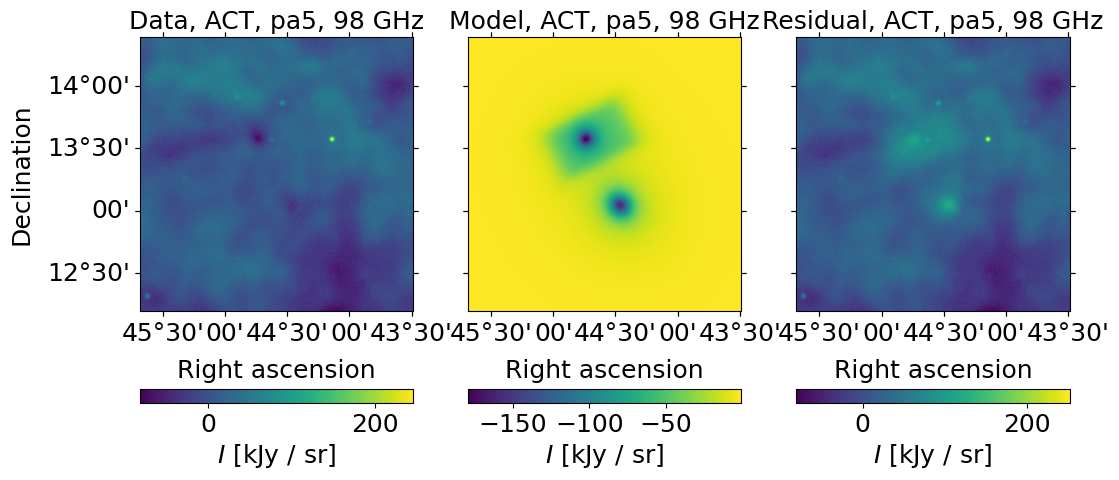

In [14]:
chain = "/home/gill/research/ACT/bridge/a399_a401/case15/chain.h5"
config = "/home/gill/research/ACT/multi-freq-bridge/configs/case15_ajay.yaml"

map_maker(chain, config, 
          labels=labels, burnin=1, thin=1)

In [5]:
labels = [r'$RA_{\rm A401}$', 
            r'$DEC_{\rm A401}$', 
            r'$\beta_{\rm A401}$', 
            r'$r_{\rm c, A401}$ [$^{\prime}$]', 
            r'$e_{\rm A401}$', 
            r'$\theta_{\rm A401}$', 
            r'$\tau_{\rm A401}$', 
            r'$T_{\rm e, A401}$', 
            r'$A_{\rm D, A401}$',
            
            r'$RA_{\rm A399}$', 
            r'$DEC_{\rm A399}$', 
            r'$\beta_{\rm A399}$', 
            r'$r_{\rm c, A399}$ [$^{\prime}$]', 
            r'$e_{\rm A399}$', 
            r'$\theta_{\rm A399}$', 
            r'$\tau_{\rm A399}$', 
            r'$T_{\rm e, A399}$', 
            r'$A_{\rm D, A399}$',
            
            r"$RA_{\rm fil}",
            r"$DEC_{\rm fil}",
            r"$L_{\rm fil}$",
            r"$W_{\rm fil}$",
            r'$\tau_{\rm fil}$',
            r'$T_{\rm e, fil}$',
            r'$A_{\rm D, fil}$',
            
            r"$v_{r, avg}$",
            
            "ps1_A_150_pa5",
            "ps1_A_98_pa5",
            "ps_A_150_pa6",
            "ps_A_98_pa6"]